## Imports

In [1]:
import os
import cv2
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import albumentations as A

 ## Load dataset paths and labels

In [2]:
DATASET_PATH = "/kaggle/input/datasets/ismailpromus/skin-diseases-image-dataset/IMG_CLASSES"
VALID_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp")

records = []
for cls in os.listdir(DATASET_PATH):
    cls_path = os.path.join(DATASET_PATH, cls)
    if not os.path.isdir(cls_path):
        continue
    for fname in os.listdir(cls_path):
        if fname.lower().endswith(VALID_EXTENSIONS):
            fpath = os.path.join(cls_path, fname)
            records.append({
                "path": fpath,
                "class": cls,
                "size_kb": os.path.getsize(fpath) / 1024
            })

df = pd.DataFrame(records)

print(f"Total images: {len(df)}")
print(f"Number of classes: {df['class'].nunique()}")

Total images: 27153
Number of classes: 10


## Class distribution and imbalance check

In [3]:
class_counts = df["class"].value_counts()
imbalance_ratio = class_counts.max() / class_counts.min()

print("Class distribution:")
print(class_counts)
print(f"\nImbalance ratio: {imbalance_ratio:.2f}")

Class distribution:
class
5. Melanocytic Nevi (NV) - 7970                                     7970
4. Basal Cell Carcinoma (BCC) 3323                                  3323
2. Melanoma 15.75k                                                  3140
10. Warts Molluscum and other Viral Infections - 2103               2103
6. Benign Keratosis-like Lesions (BKL) 2624                         2079
7. Psoriasis pictures Lichen Planus and related diseases - 2k       2055
8. Seborrheic Keratoses and other Benign Tumors - 1.8k              1847
9. Tinea Ringworm Candidiasis and other Fungal Infections - 1.7k    1702
1. Eczema 1677                                                      1677
3. Atopic Dermatitis - 1.25k                                        1257
Name: count, dtype: int64

Imbalance ratio: 6.34


## Visualize class distribution

/tmp/ipykernel_58/407097247.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.values, y=class_counts.index, palette="viridis")


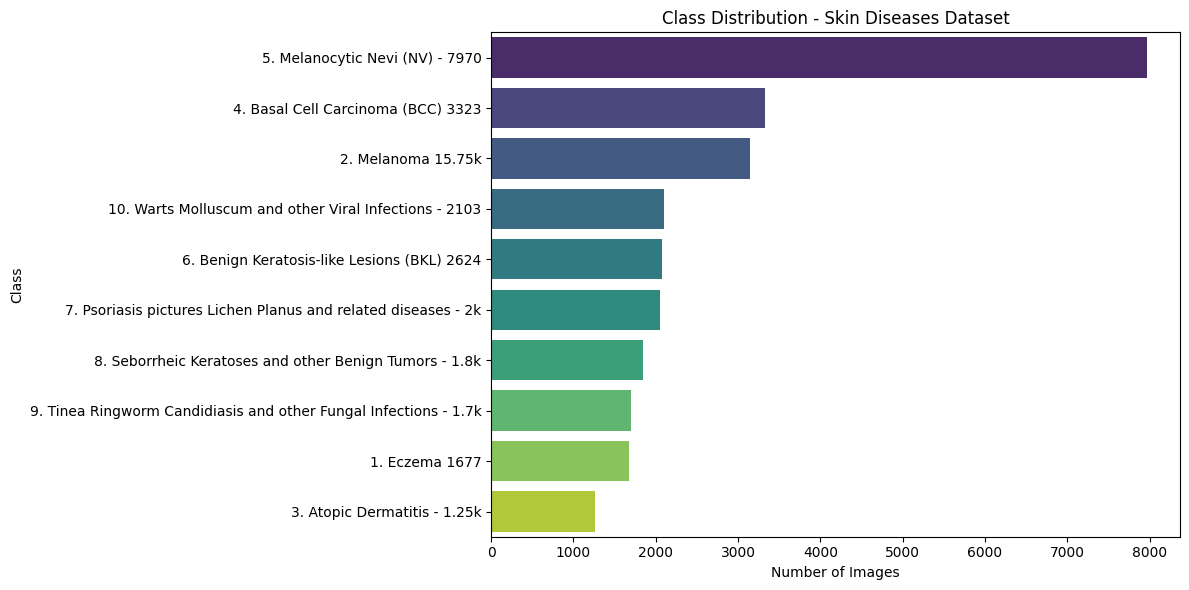

In [4]:
plt.figure(figsize=(12, 6))
sns.barplot(x=class_counts.values, y=class_counts.index, palette="viridis")
plt.title("Class Distribution - Skin Diseases Dataset")
plt.xlabel("Number of Images")
plt.ylabel("Class")
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150)
plt.show()

## Verify image quality (corrupted files and dimensions)

In [5]:
sample_df = df.sample(n=500, random_state=42).reset_index(drop=True)

dims = []
corrupted = []

for p in sample_df["path"]:
    img = cv2.imread(p)
    if img is None:
        corrupted.append(p)
        continue
    h, w, c = img.shape
    dims.append((w, h, c))

dims_df = pd.DataFrame(dims, columns=["width", "height", "channels"])

print(f"Corrupted images: {len(corrupted)}")
print(f"\nDimension summary:\n{dims_df.describe()}")
print(f"\nUnique channel counts: {dims_df['channels'].unique()}")

Corrupted images: 0

Dimension summary:
             width       height  channels
count   500.000000   500.000000     500.0
mean    699.554000   589.022000       3.0
std     214.756102   230.384025       0.0
min     294.000000   222.000000       3.0
25%     600.000000   450.000000       3.0
50%     660.000000   479.000000       3.0
75%     805.000000   720.000000       3.0
max    1024.000000  1024.000000       3.0

Unique channel counts: [3]


## Stratified train/validation/test split

In [7]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.3,
    stratify=df["class"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["class"],
    random_state=42
)

print(f"Train size: {len(train_df)}")
print(f"Validation size: {len(val_df)}")
print(f"Test size: {len(test_df)}")

Train size: 19007
Validation size: 4073
Test size: 4073


## Determine augmentation targets per class

In [8]:
train_counts = train_df["class"].value_counts()
target_count = int(train_counts.median() * 1.5)

augmentation_needed = {
    cls: max(0, target_count - count)
    for cls, count in train_counts.items()
}

print(f"Target count per class: {target_count}\n")
print("Images needed per class:")
for cls, need in augmentation_needed.items():
    print(f"{cls}: {need}")

Target count per class: 2170

Images needed per class:
5. Melanocytic Nevi (NV) - 7970: 0
4. Basal Cell Carcinoma (BCC) 3323: 0
2. Melanoma 15.75k: 0
10. Warts Molluscum and other Viral Infections - 2103: 698
6. Benign Keratosis-like Lesions (BKL) 2624: 715
7. Psoriasis pictures Lichen Planus and related diseases - 2k: 731
8. Seborrheic Keratoses and other Benign Tumors - 1.8k: 877
9. Tinea Ringworm Candidiasis and other Fungal Infections - 1.7k: 979
1. Eczema 1677: 996
3. Atopic Dermatitis - 1.25k: 1290


## Define augmentation pipeline

In [9]:
augmentation_pipeline = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.Rotate(limit=25, p=0.6),
    A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.5),
    A.Affine(translate_percent=0.05, scale=(0.9, 1.1), rotate=(-15, 15), p=0.4),
    A.GaussianBlur(blur_limit=(3, 5), p=0.2),
])

## Generate augmented images for underrepresented classes

In [10]:
AUGMENTED_DIR = "/kaggle/working/augmented_images"
os.makedirs(AUGMENTED_DIR, exist_ok=True)

augmented_records = []

for cls, need in augmentation_needed.items():
    if need <= 0:
        continue

    cls_dir = os.path.join(AUGMENTED_DIR, cls)
    os.makedirs(cls_dir, exist_ok=True)
    cls_images = train_df[train_df["class"] == cls]["path"].tolist()

    for i in range(need):
        source_path = cls_images[i % len(cls_images)]
        img = cv2.imread(source_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        augmented = augmentation_pipeline(image=img)["image"]
        augmented_bgr = cv2.cvtColor(augmented, cv2.COLOR_RGB2BGR)

        save_name = f"aug_{i}_{os.path.basename(source_path)}"
        save_path = os.path.join(cls_dir, save_name)
        cv2.imwrite(save_path, augmented_bgr)

        augmented_records.append({
            "path": save_path,
            "class": cls,
            "size_kb": os.path.getsize(save_path) / 1024
        })

    print(f"{cls}: generated {need} images")

print(f"\nTotal augmented images: {len(augmented_records)}")

10. Warts Molluscum and other Viral Infections - 2103: generated 698 images
6. Benign Keratosis-like Lesions (BKL) 2624: generated 715 images
7. Psoriasis pictures Lichen Planus and related diseases - 2k: generated 731 images
8. Seborrheic Keratoses and other Benign Tumors - 1.8k: generated 877 images
9. Tinea Ringworm Candidiasis and other Fungal Infections - 1.7k: generated 979 images
1. Eczema 1677: generated 996 images
3. Atopic Dermatitis - 1.25k: generated 1290 images

Total augmented images: 6286


## Merge augmented images and verify final balance

In [11]:
augmented_df = pd.DataFrame(augmented_records)
final_train_df = pd.concat([train_df, augmented_df], ignore_index=True)

final_counts = final_train_df["class"].value_counts()
final_imbalance_ratio = final_counts.max() / final_counts.min()

print(f"Final train size: {len(final_train_df)}")
print(f"\nFinal class distribution:\n{final_counts}")
print(f"\nFinal imbalance ratio: {final_imbalance_ratio:.2f}")

Final train size: 25293

Final class distribution:
class
5. Melanocytic Nevi (NV) - 7970                                     5579
4. Basal Cell Carcinoma (BCC) 3323                                  2326
2. Melanoma 15.75k                                                  2198
9. Tinea Ringworm Candidiasis and other Fungal Infections - 1.7k    2170
10. Warts Molluscum and other Viral Infections - 2103               2170
3. Atopic Dermatitis - 1.25k                                        2170
8. Seborrheic Keratoses and other Benign Tumors - 1.8k              2170
6. Benign Keratosis-like Lesions (BKL) 2624                         2170
1. Eczema 1677                                                      2170
7. Psoriasis pictures Lichen Planus and related diseases - 2k       2170
Name: count, dtype: int64

Final imbalance ratio: 2.57


## Organize all splits into folders

In [12]:
FINAL_DIR = "/kaggle/working/processed_dataset"

for split_name, split_df in [("train", final_train_df), ("val", val_df), ("test", test_df)]:
    for cls in split_df["class"].unique():
        os.makedirs(os.path.join(FINAL_DIR, split_name, cls), exist_ok=True)

    for _, row in split_df.iterrows():
        dst = os.path.join(FINAL_DIR, split_name, row["class"], os.path.basename(row["path"]))
        shutil.copy(row["path"], dst)

    print(f"{split_name}: copied {len(split_df)} images")

train: copied 25293 images
val: copied 4073 images
test: copied 4073 images
